# Imports

In [1]:
import numpy as np
import pandas as pd
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import average_precision_score, roc_auc_score

import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

# cpu = no GPU needed — works on any laptop
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')   # Will show: cpu
print(' Imports done!')

Device: cpu
 Imports done!


# Load data

In [2]:
data = joblib.load('../models/data_splits.pkl')

X_train    = data['X_train']
y_train    = data['y_train']
X_train_sm = data['X_train_sm']   # SMOTE balanced version
y_train_sm = data['y_train_sm']
X_val      = data['X_val']
y_val      = data['y_val']
X_test     = data['X_test']
y_test     = data['y_test']
feature_names = data['feature_names']

print(f'Train (SMOTE) : {X_train_sm.shape}')
print(f'Validation    : {X_val.shape}')
print(f'Test          : {X_test.shape}')
print(' Data loaded!')

Train (SMOTE) : (218920, 33)
Validation    : (28481, 33)
Test          : (56962, 33)
 Data loaded!


#  Model 1: Logistic Regression

In [3]:
# Simplest model — draws a straight line to separate fraud from legit
# Good baseline to compare all other models against
print('Training Logistic Regression...')
t0 = time.time()

lr_model = LogisticRegression(
    C=0.1,                    # Regularization: smaller = simpler model, less overfit
    class_weight='balanced',  # Auto-weights fraud higher to handle imbalance
    max_iter=1000,            # Max iterations for solver to converge
    solver='lbfgs',           # Optimization algorithm
    random_state=42,
    n_jobs=-1                 # Use ALL CPU cores
)

lr_model.fit(X_train_sm, y_train_sm)
print(f' Done in {time.time()-t0:.1f}s')

# predict_proba returns [P(legit), P(fraud)] per row
# [:, 1] = take only the fraud probability column
lr_val_proba = lr_model.predict_proba(X_val)[:, 1]

lr_ap  = average_precision_score(y_val, lr_val_proba)  # Precision-Recall AUC
lr_roc = roc_auc_score(y_val, lr_val_proba)            # ROC-AUC

print(f'  PR-AUC  : {lr_ap:.4f}')
print(f'  ROC-AUC : {lr_roc:.4f}')

joblib.dump(lr_model, '../models/logistic_regression.pkl')
print(' Saved!')

Training Logistic Regression...
 Done in 1.8s
  PR-AUC  : 0.6274
  ROC-AUC : 0.9513
 Saved!


# Model 2: Random Forest

In [4]:
# Many decision trees voting together — majority wins
# Each tree sees a random subset of rows and features
print('Training Random Forest... (2-3 minutes on CPU)')
t0 = time.time()

rf_model = RandomForestClassifier(
    n_estimators=200,         # Number of trees — more = better but slower
    max_depth=12,             # Max depth per tree — limits overfitting
    min_samples_split=10,     # Min samples needed to split a node
    min_samples_leaf=5,       # Min samples in each leaf node
    max_features='sqrt',      # Each tree uses sqrt(features) randomly — adds variety
    class_weight='balanced',  # Weights fraud higher automatically
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_sm, y_train_sm)
print(f' Done in {time.time()-t0:.1f}s')

rf_val_proba = rf_model.predict_proba(X_val)[:, 1]
rf_ap  = average_precision_score(y_val, rf_val_proba)
rf_roc = roc_auc_score(y_val, rf_val_proba)

print(f'  PR-AUC  : {rf_ap:.4f}')
print(f'  ROC-AUC : {rf_roc:.4f}')

joblib.dump(rf_model, '../models/random_forest.pkl')
print(' Saved!')

Training Random Forest... (2-3 minutes on CPU)
 Done in 139.2s
  PR-AUC  : 0.7669
  ROC-AUC : 0.9698
 Saved!


# Model 3: XGBoost

In [5]:
# Best performer for fraud detection
# Each tree CORRECTS the errors of the previous tree
# scale_pos_weight is the key parameter — tells model how rare fraud is

neg = (y_train == 0).sum()   # Count legit
pos = (y_train == 1).sum()   # Count fraud
scale_pos = neg / pos        # e.g. 227451 / 394 ≈ 577

print(f'scale_pos_weight = {scale_pos:.1f}')
print('Training XGBoost... (3-5 minutes on CPU)')
t0 = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,          # Number of boosting rounds (trees)
    max_depth=4,               # Shallow trees — generalizes better
    learning_rate=0.05,        # How much each tree corrects errors
    subsample=0.8,             # Each tree uses 80% of rows randomly
    colsample_bytree=0.8,      # Each tree uses 80% of features randomly
    scale_pos_weight=scale_pos,# KEY: compensates for class imbalance
    eval_metric='aucpr',       # Optimize Precision-Recall AUC
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
    tree_method='hist'         # Faster CPU histogram method
)

# eval_set monitors val performance each round
# verbose=50 prints progress every 50 rounds
xgb_model.fit(
    X_train, y_train,          # Use ORIGINAL data — scale_pos_weight handles imbalance
    eval_set=[(X_val, y_val)],
    verbose=50
)
print(f'\n Done in {time.time()-t0:.1f}s')

xgb_val_proba = xgb_model.predict_proba(X_val)[:, 1]
xgb_ap  = average_precision_score(y_val, xgb_val_proba)
xgb_roc = roc_auc_score(y_val, xgb_val_proba)

print(f'  PR-AUC  : {xgb_ap:.4f}')
print(f'  ROC-AUC : {xgb_roc:.4f}')

joblib.dump(xgb_model, '../models/xgboost.pkl')
print(' Saved!')

scale_pos_weight = 576.9
Training XGBoost... (3-5 minutes on CPU)
[0]	validation_0-aucpr:0.10398
[50]	validation_0-aucpr:0.66731
[100]	validation_0-aucpr:0.64251
[150]	validation_0-aucpr:0.65135
[200]	validation_0-aucpr:0.74839
[250]	validation_0-aucpr:0.76737
[299]	validation_0-aucpr:0.76918

 Done in 13.2s
  PR-AUC  : 0.7707
  ROC-AUC : 0.9661
 Saved!


# Model 4: Isolation Forest

In [6]:
# UNSUPERVISED — does NOT need fraud labels to train
# Idea: fraud transactions are easier to "isolate" because they are rare and different
# It builds random trees and measures how quickly each sample gets isolated
print('Training Isolation Forest...')
t0 = time.time()

iso_model = IsolationForest(
    n_estimators=200,        # Number of isolation trees
    contamination=0.002,     # Expected fraud fraction (~0.17%)
    max_samples='auto',      # Samples per tree
    random_state=42,
    n_jobs=-1
)

# No y_train here! Unsupervised = no labels needed
iso_model.fit(X_train)
print(f' Done in {time.time()-t0:.1f}s')

# score_samples: more negative = more anomalous
# We negate (-) so higher score = more likely fraud (consistent with other models)
iso_scores = -iso_model.score_samples(X_val)

iso_ap  = average_precision_score(y_val, iso_scores)
iso_roc = roc_auc_score(y_val, iso_scores)

print(f'  PR-AUC  : {iso_ap:.4f}  (lower expected — unsupervised)')
print(f'  ROC-AUC : {iso_roc:.4f}')

joblib.dump(iso_model, '../models/isolation_forest.pkl')
print(' Saved!')

Training Isolation Forest...
 Done in 4.7s
  PR-AUC  : 0.0583  (lower expected — unsupervised)
  ROC-AUC : 0.9291
 Saved!


# Model 5: Autoencoder (define architecture)

In [7]:
# Autoencoder = neural network trained to RECONSTRUCT normal transactions
# ENCODER compresses:  31 features → 16 → 8
# DECODER expands:     8 → 16 → 31
# Trained on LEGIT only — learns what "normal" looks like
# At prediction: fraud has HIGH reconstruction error (looks "wrong" to the model)

class FraudAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        # Encoder: compress input down to 8 numbers
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),  # Layer: input_dim → 32 neurons
            nn.ReLU(),                 # Activation: max(0, x) — adds non-linearity
            nn.Dropout(0.2),           # Randomly drops 20% neurons — prevents overfit
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8)           # Bottleneck: most compressed form
        )

        # Decoder: expand 8 numbers back to original size
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)   # Output same size as input
        )

    def forward(self, x):
        encoded = self.encoder(x)      # Compress
        decoded = self.decoder(encoded)# Reconstruct
        return decoded

input_dim = X_train.shape[1]
ae_model  = FraudAutoencoder(input_dim).to(device)

print('Autoencoder architecture:')
print(ae_model)
total_params = sum(p.numel() for p in ae_model.parameters())
print(f'\nTotal parameters: {total_params:,}')

Autoencoder architecture:
FraudAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=33, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=33, bias=True)
  )
)

Total parameters: 3,529


#  Train Autoencoder

Training on 199,019 legit transactions only
Training for 15 epochs...
  Epoch [5/15]  Loss: 0.388956
  Epoch [10/15]  Loss: 0.341366
  Epoch [15/15]  Loss: 0.312851


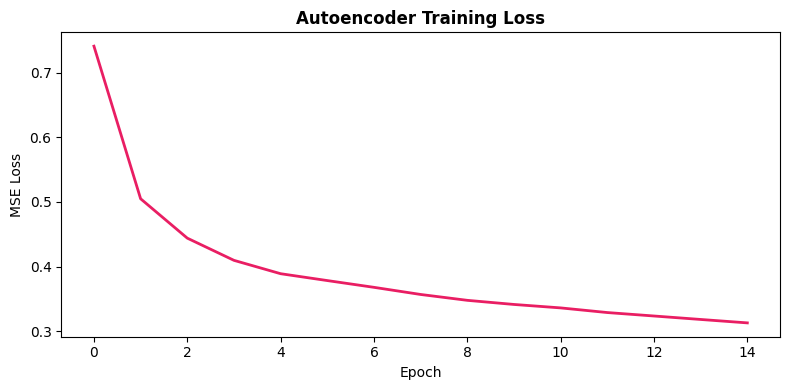

In [8]:
# Train ONLY on legitimate transactions
X_train_legit = X_train[y_train == 0]
print(f'Training on {len(X_train_legit):,} legit transactions only')

# Convert to PyTorch tensors (PyTorch works with tensors, not DataFrames)
X_tensor = torch.FloatTensor(X_train_legit.values).to(device)
dataset  = TensorDataset(X_tensor, X_tensor)  # Input = Target (reconstruction task)
loader   = DataLoader(dataset, batch_size=512, shuffle=True)

# Loss function: Mean Squared Error — how different is reconstruction from input
criterion = nn.MSELoss()
# Adam optimizer: automatically adjusts learning rate during training
optimizer = torch.optim.Adam(ae_model.parameters(), lr=0.001)

EPOCHS = 15   # Keep low for CPU — increase to 30 for better results
losses = []

print(f'Training for {EPOCHS} epochs...')
for epoch in range(EPOCHS):
    ae_model.train()      # Training mode (enables Dropout)
    epoch_loss = 0

    for batch_X, batch_y in loader:
        optimizer.zero_grad()              # Clear old gradients
        output = ae_model(batch_X)         # Forward pass: reconstruct
        loss   = criterion(output, batch_y)# Compute error
        loss.backward()                    # Backprop: compute gradients
        optimizer.step()                   # Update weights
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f'  Epoch [{epoch+1}/{EPOCHS}]  Loss: {avg_loss:.6f}')

# Plot training loss — should decrease over epochs
plt.figure(figsize=(8, 4))
plt.plot(losses, color='#E91E63', linewidth=2)
plt.title('Autoencoder Training Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.tight_layout()
plt.show()

# Evaluate Autoencoder

In [9]:
# Compute reconstruction error on validation set
# High error = transaction looks abnormal = likely fraud
ae_model.eval()  # Evaluation mode (disables Dropout)

with torch.no_grad():  # No gradient computation — saves memory
    X_val_tensor = torch.FloatTensor(X_val.values).to(device)
    val_reconstructed = ae_model(X_val_tensor)
    # Per-row mean squared error
    ae_errors = ((X_val_tensor - val_reconstructed) ** 2).mean(dim=1).cpu().numpy()

ae_ap  = average_precision_score(y_val, ae_errors)
ae_roc = roc_auc_score(y_val, ae_errors)

print(f'  PR-AUC  : {ae_ap:.4f}')
print(f'  ROC-AUC : {ae_roc:.4f}')

# Save model weights and config
torch.save(ae_model.state_dict(), '../models/autoencoder.pt')
joblib.dump({'input_dim': input_dim}, '../models/autoencoder_config.pkl')
print('💾 Autoencoder saved!')

  PR-AUC  : 0.3381
  ROC-AUC : 0.9349
💾 Autoencoder saved!


# Compare all models

In [10]:
results = pd.DataFrame({
    'Model'  : ['Logistic Regression', 'Random Forest',
                'XGBoost', 'Isolation Forest', 'Autoencoder'],
    'PR-AUC' : [lr_ap, rf_ap, xgb_ap, iso_ap, ae_ap],
    'ROC-AUC': [lr_roc, rf_roc, xgb_roc, iso_roc, ae_roc]
}).sort_values('PR-AUC', ascending=False)

print('=== Model Comparison (Validation Set) ===')
print(results.to_string(index=False))
print('\n💡 Use PR-AUC as your main metric — more accurate for imbalanced data')

# Save val predictions for NB4
joblib.dump({
    'lr_val_proba' : lr_val_proba,
    'rf_val_proba' : rf_val_proba,
    'xgb_val_proba': xgb_val_proba,
    'iso_scores'   : iso_scores,
    'ae_errors'    : ae_errors
}, '../models/val_predictions.pkl')

print(' All predictions saved!')
print('  Now open NB4!')

=== Model Comparison (Validation Set) ===
              Model   PR-AUC  ROC-AUC
            XGBoost 0.770669 0.966100
      Random Forest 0.766926 0.969841
Logistic Regression 0.627448 0.951289
        Autoencoder 0.338099 0.934916
   Isolation Forest 0.058279 0.929074

💡 Use PR-AUC as your main metric — more accurate for imbalanced data
 All predictions saved!
  Now open NB4!
